## UK House Prices
### Notebook 1 - Data Cleaning and Preparation

Source
https://www.gov.uk/government/statistical-data-sets/uk-house-price-index-data-downloads-december-

Information on dataset
https://www.gov.uk/government/publications/about-the-uk-house-price-index/about-the-uk-house-price-index#data-tables


1. Import house prices dataset
2. Initial data inspection
3. Clean Data

   

In [169]:
import numpy as np
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.dates as mdates
import seaborn as sns

### 1. Import house prices dataset

In [170]:
filepath = "../data/UK-HPI-full-file-2025-12.csv"

#### Create a dataframe from csv

In [171]:
data = pd.read_csv(filepath)

### 2. Initial data inspection

#### Examine data

In [172]:
print(f"Data shape:{data.shape}")
data.head()

Data shape:(149085, 54)


,Date,RegionName,AreaCode,AveragePrice,Index,IndexSA,1m%Change,12m%Change,AveragePriceSA,SalesVolume,...,NewPrice,NewIndex,New1m%Change,New12m%Change,NewSalesVolume,OldPrice,OldIndex,Old1m%Change,Old12m%Change,OldSalesVolume
0,01/01/2004,Aberdeenshire,S12000034,84638,41.1,NaN,NaN,NaN,NaN,388.0,...,112843.0,40.7,NaN,NaN,103.0,81273.0,41.0,NaN,NaN,285.0
1,01/02/2004,Aberdeenshire,S12000034,84623,41.1,NaN,0.0,NaN,NaN,326.0,...,113061.0,40.8,0.2,NaN,107.0,81194.0,40.9,-0.1,NaN,219.0
2,01/03/2004,Aberdeenshire,S12000034,86536,42.1,NaN,2.3,NaN,NaN,453.0,...,115218.0,41.6,1.9,NaN,140.0,83137.0,41.9,2.4,NaN,313.0
3,01/04/2004,Aberdeenshire,S12000034,87373,42.5,NaN,1.0,NaN,NaN,571.0,...,115247.0,41.6,0.0,NaN,180.0,84241.0,42.5,1.3,NaN,391.0
4,01/05/2004,Aberdeenshire,S12000034,89493,43.5,NaN,2.4,NaN,NaN,502.0,...,117377.0,42.4,1.8,NaN,167.0,86466.0,43.6,2.6,NaN,335.0


In [173]:
data.describe()

,AveragePrice,Index,IndexSA,1m%Change,12m%Change,AveragePriceSA,SalesVolume,DetachedPrice,DetachedIndex,Detached1m%Change,...,NewPrice,NewIndex,New1m%Change,New12m%Change,NewSalesVolume,OldPrice,OldIndex,Old1m%Change,Old12m%Change,OldSalesVolume
count,1.490850e+05,149085.000000,5244.000000,148632.000000,144225.000000,5244.000000,144618.000000,1.422840e+05,142284.000000,141889.000000,...,1.416640e+05,141664.000000,141268.000000,136936.000000,138483.000000,1.418680e+05,141868.000000,141472.000000,137140.000000,141858.000000
mean,1.831012e+05,59.835763,62.132113,0.526866,6.100826,168752.656941,1252.600105,3.420380e+05,59.933395,0.461848,...,2.196692e+05,61.681981,0.497958,6.245756,135.956161,1.847985e+05,60.045649,0.472946,6.054274,1138.200045
std,1.311841e+05,26.619737,25.039764,1.934405,8.622357,94882.354669,7707.191260,3.432452e+05,25.206280,1.697813,...,1.342548e+05,26.401143,1.751680,7.974581,843.840990,1.310111e+05,25.507217,1.730925,8.408653,6965.933714
min,2.553000e+03,0.800000,13.900000,-30.300000,-35.800000,39008.000000,2.000000,4.011700e+04,9.400000,-19.600000,...,2.244300e+04,8.000000,-29.800000,-28.900000,1.000000,2.271600e+04,9.000000,-30.600000,-30.300000,2.000000
25%,1.005410e+05,38.200000,46.600000,-0.500000,1.100000,116135.000000,140.000000,1.785228e+05,41.200000,-0.500000,...,1.279912e+05,42.400000,-0.500000,1.700000,10.000000,1.021160e+05,40.900000,-0.500000,1.000000,126.000000
50%,1.547560e+05,61.000000,62.600000,0.500000,5.100000,153018.500000,215.000000,2.603840e+05,60.000000,0.400000,...,1.982200e+05,61.600000,0.500000,5.400000,21.000000,1.549365e+05,60.800000,0.500000,5.100000,193.000000
75%,2.301380e+05,80.300000,80.400000,1.400000,10.100000,209241.750000,376.000000,3.961765e+05,79.800000,1.400000,...,2.780390e+05,82.800000,1.500000,10.100000,46.000000,2.312262e+05,79.600000,1.400000,10.200000,343.000000
max,1.656986e+06,153.100000,110.000000,35.300000,98.400000,574627.000000,183609.000000,5.820174e+06,147.000000,34.800000,...,1.414204e+06,149.600000,34.900000,96.200000,21097.000000,1.665089e+06,152.700000,35.600000,98.600000,166098.000000


#### Review missing variables


In [174]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 149085 entries, 0 to 149084
Data columns (total 54 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   Date                    149085 non-null  str    
 1   RegionName              149085 non-null  str    
 2   AreaCode                149085 non-null  str    
 3   AveragePrice            149085 non-null  int64  
 4   Index                   149085 non-null  float64
 5   IndexSA                 5244 non-null    float64
 6   1m%Change               148632 non-null  float64
 7   12m%Change              144225 non-null  float64
 8   AveragePriceSA          5244 non-null    float64
 9   SalesVolume             144618 non-null  float64
 10  DetachedPrice           142284 non-null  float64
 11  DetachedIndex           142284 non-null  float64
 12  Detached1m%Change       141889 non-null  float64
 13  Detached12m%Change      137568 non-null  float64
 14  SemiDetachedPrice       142284 

We can see there are 53 columns, and a lot have missing values. We will reduce some of these features down.
Some of these variables are essentially the same - Average Price, Index, IndexSA and AveragePrice SA, but let's inspect the index to see how it is implemented.

In [175]:
data.groupby('RegionName')['Index'].describe().sort_values(by='max',ascending=False)

,count,mean,std,min,25%,50%,75%,max
RegionName,,,,,,,,
City of Aberdeen,264.0,114.121591,20.735505,55.1,103.950,117.60,126.125,153.1
Ards and North Down,252.0,87.740476,19.193993,62.2,73.150,81.50,101.325,140.5
Mid Ulster,252.0,85.641667,19.480325,55.7,71.300,81.00,100.250,137.2
Armagh City Banbridge and Craigavon,252.0,83.413095,19.761751,54.7,69.450,78.00,97.975,137.1
Belfast,252.0,85.039286,18.872139,55.5,70.900,81.65,99.550,134.8
...,...,...,...,...,...,...,...,...
Sutton,372.0,56.766667,26.220627,15.4,38.200,52.10,82.900,100.0
Croydon,372.0,57.647849,26.250962,16.0,39.275,52.30,86.825,100.0
Thanet,372.0,51.231183,25.236037,12.7,31.850,48.20,73.375,100.0


So we can see all seem to start at different indexes, and City of Aberdeen seems to contain the highest. Indexes are set for individual counties at some point, and are changed from that original zero index.

Variables such as 1m% change and 12m% change are encoding growth.

Then there is segmented market data; splitting into type of property; detached, semi-detached, flat, purchase type; mortgage, cash, buyer type and age (new/old). We will drop the segmented market data, to focus on modelling across these segments.

### 3. Clean data
### Drop variables not required

So we will keep 'Date', 'RegionName', 'AreaCode', 'AveragePrice', 'Index', '1m%Change', '12m%Change', 'SalesVolume'. 

In [176]:
data = data[['Date','RegionName','AreaCode','AveragePrice','Index','1m%Change','12m%Change','SalesVolume']]

### Check duplicate data

In [177]:
data.duplicated().sum()

np.int64(0)

### Clean dates

In [179]:
# inspect dates
print(data.groupby('RegionName')['Date'].unique())

# check datetime format
print(type(data['Date'].iloc[0]))

RegionName
Aberdeenshire               [01/01/2004, 01/02/2004, 01/03/2004, 01/04/200...
Adur                        [01/01/1995, 01/02/1995, 01/03/1995, 01/04/199...
Amber Valley                [01/01/1995, 01/02/1995, 01/03/1995, 01/04/199...
Angus                       [01/01/2004, 01/02/2004, 01/03/2004, 01/04/200...
Antrim and Newtownabbey     [01/01/2005, 01/02/2005, 01/03/2005, 01/04/200...
                                                  ...                        
Wychavon                    [01/01/1995, 01/02/1995, 01/03/1995, 01/04/199...
Wyre                        [01/01/1995, 01/02/1995, 01/03/1995, 01/04/199...
Wyre Forest                 [01/01/1995, 01/02/1995, 01/03/1995, 01/04/199...
York                        [01/01/1995, 01/02/1995, 01/03/1995, 01/04/199...
Yorkshire and The Humber    [01/04/1968, 01/05/1968, 01/06/1968, 01/07/196...
Name: Date, Length: 405, dtype: object
<class 'str'>


There seems to be some variation in dates across the data, let's convert to datetime and inspect missing values.

In [180]:
data['Date'] = pd.to_datetime(
    data['Date'].astype(str).str.strip(),
    format='%d/%m/%Y',
    errors='raise'
)

In [181]:
# check formatting
data['Date'].tail(10).apply(lambda x: (x, x.day, x.month))

149075     (2025-03-01 00:00:00, 1, 3)
149076     (2025-04-01 00:00:00, 1, 4)
149077     (2025-05-01 00:00:00, 1, 5)
149078     (2025-06-01 00:00:00, 1, 6)
149079     (2025-07-01 00:00:00, 1, 7)
149080     (2025-08-01 00:00:00, 1, 8)
149081     (2025-09-01 00:00:00, 1, 9)
149082    (2025-10-01 00:00:00, 1, 10)
149083    (2025-11-01 00:00:00, 1, 11)
149084    (2025-12-01 00:00:00, 1, 12)
Name: Date, dtype: object

In [182]:
data.sort_values(by=['RegionName','Date'])

,Date,RegionName,AreaCode,AveragePrice,Index,1m%Change,12m%Change,SalesVolume
0,2004-01-01,Aberdeenshire,S12000034,84638,41.1,NaN,NaN,388.0
1,2004-02-01,Aberdeenshire,S12000034,84623,41.1,0.0,NaN,326.0
2,2004-03-01,Aberdeenshire,S12000034,86536,42.1,2.3,NaN,453.0
3,2004-04-01,Aberdeenshire,S12000034,87373,42.5,1.0,NaN,571.0
4,2004-05-01,Aberdeenshire,S12000034,89493,43.5,2.4,NaN,502.0
...,...,...,...,...,...,...,...,...
149080,2025-08-01,Yorkshire and The Humber,E12000003,206107,107.6,0.9,2.0,5471.0
149081,2025-09-01,Yorkshire and The Humber,E12000003,206581,107.8,0.2,3.9,4745.0
149082,2025-10-01,Yorkshire and The Humber,E12000003,206401,107.7,-0.1,3.2,4961.0
149083,2025-11-01,Yorkshire and The Humber,E12000003,209467,109.3,1.5,3.8,NaN


### Missing data

In [183]:
data.isna().sum()

Date               0
RegionName         0
AreaCode           0
AveragePrice       0
Index              0
1m%Change        453
12m%Change      4860
SalesVolume     4467
dtype: int64

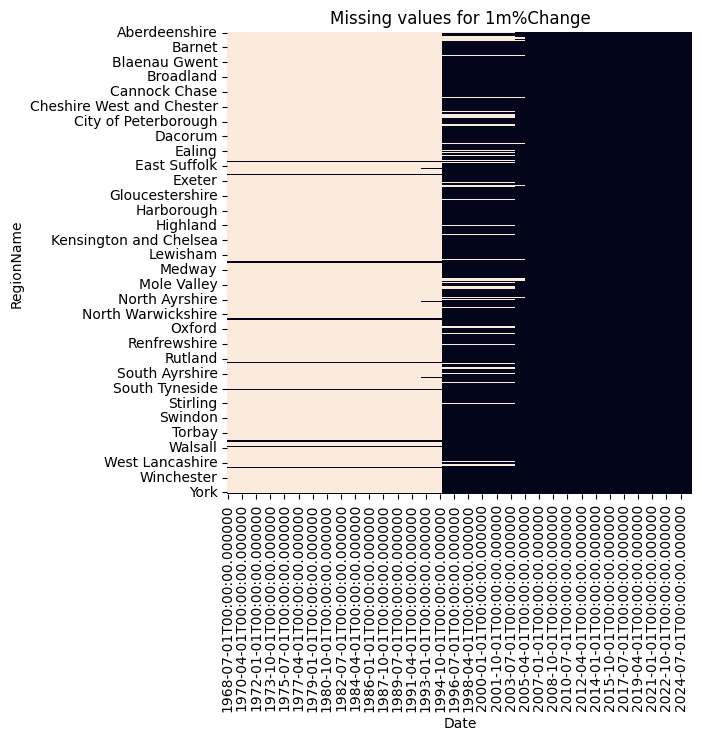

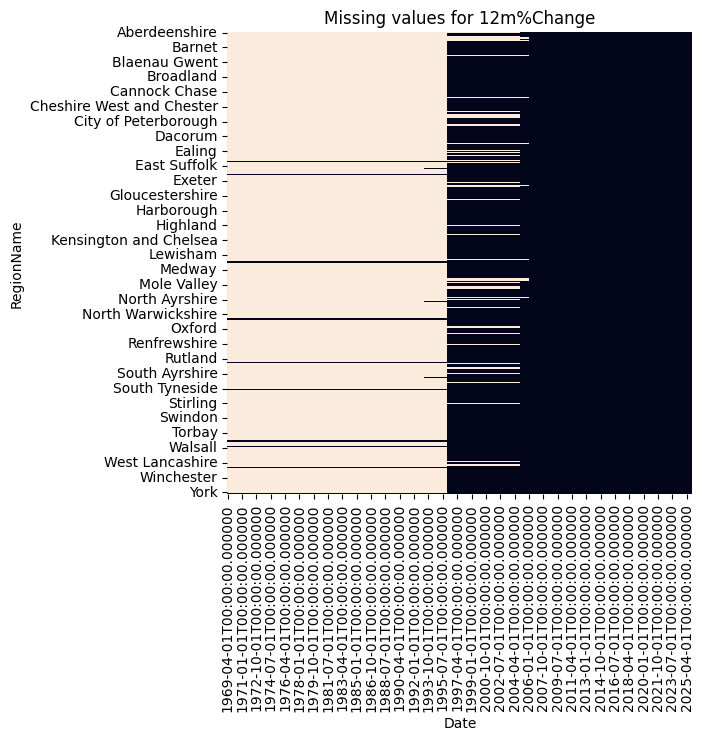

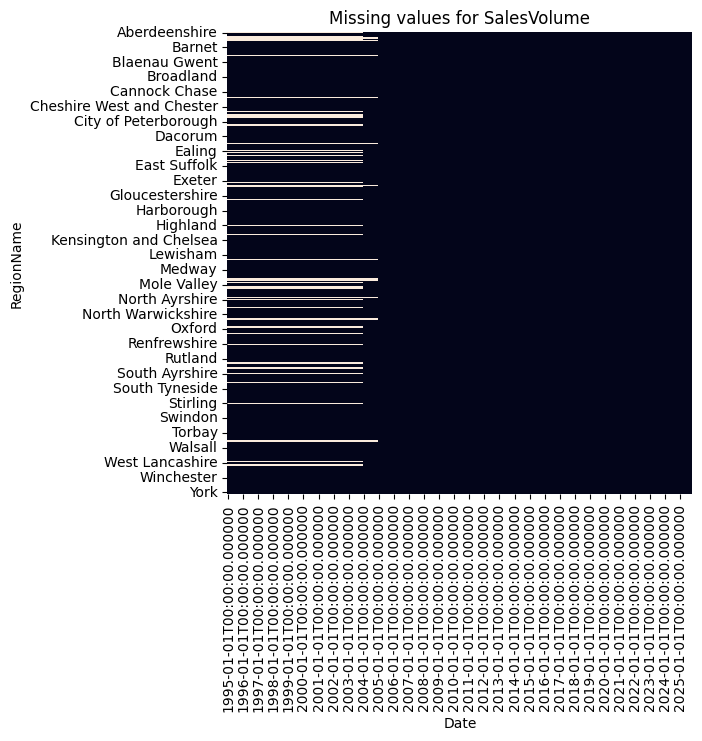

In [184]:
piv_tab_1m = data.pivot_table(values='1m%Change',index='RegionName',columns='Date')
piv_tab_12m = data.pivot_table(values='12m%Change',index='RegionName',columns='Date')
piv_tab_SV = data.pivot_table(values='SalesVolume',index='RegionName',columns='Date')

piv_tabs = [("1m%Change",piv_tab_1m), ("12m%Change", piv_tab_12m), ("SalesVolume", piv_tab_SV)]

def plot_piv_tab_heatmap(piv_tab):
    plt.figure(figsize=(6,6))
    
    sns.heatmap(piv_tab[1].isna(),cbar=False)
    plt.title(f"Missing values for {piv_tab[0]}")
    plt.show()

for pt in piv_tabs:
    plot_piv_tab_heatmap(pt)

It seems like the missing values all occur prior to 2005.

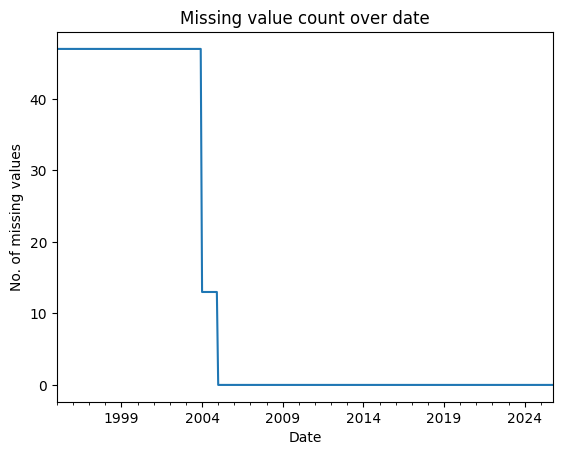

In [134]:
missing_values = piv_tab_SV.isna().sum()
missing_values.plot()
plt.ylabel("No. of missing values")
plt.title("Missing value count over date")
plt.show()

In [135]:
print("Number of missing values 2004",missing_values.loc['2004'].mean())
print("Number of missing values 2005",missing_values.loc['2005'].mean())
print("Number of missing values 2006",missing_values.loc['2006'].mean())

Number of missing values 2004 13.0
Number of missing values 2005 0.0
Number of missing values 2006 0.0


__The dataset exhibits structural missingness prior to 2006, so I restrict analysis to a fully observed balanced panel from 2005 onward.__

In [144]:
data = data[data['Date']>='2006']
data.sort_values(by=['RegionName','Date'])
data.info()

<class 'pandas.DataFrame'>
Index: 97200 entries, 24 to 149084
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Date          97200 non-null  datetime64[us]
 1   RegionName    97200 non-null  str           
 2   AreaCode      97200 non-null  str           
 3   AveragePrice  97200 non-null  int64         
 4   Index         97200 non-null  float64       
 5   1m%Change     97200 non-null  float64       
 6   12m%Change    97200 non-null  float64       
 7   SalesVolume   96390 non-null  float64       
dtypes: datetime64[us](1), float64(4), int64(1), str(2)
memory usage: 8.7 MB


There still are some missing values in SalesVolume though...

In [145]:
missing_vals_SV = data[data['SalesVolume'].isnull()].index
data_mv = data.loc[missing_vals_SV]
data_mv

,Date,RegionName,AreaCode,AveragePrice,Index,1m%Change,12m%Change,SalesVolume
262,2025-11-01,Aberdeenshire,S12000034,201555,97.9,-0.8,-0.8,NaN
263,2025-12-01,Aberdeenshire,S12000034,202362,98.3,0.4,0.3,NaN
634,2025-11-01,Adur,E07000223,372499,98.8,-0.6,0.1,NaN
635,2025-12-01,Adur,E07000223,370708,98.3,-0.5,-0.5,NaN
1006,2025-11-01,Amber Valley,E07000032,238246,107.3,0.0,7.2,NaN
...,...,...,...,...,...,...,...,...
148019,2025-12-01,Wyre Forest,E07000239,234081,102.0,0.3,1.0,NaN
148390,2025-11-01,York,E06000014,303055,98.6,-0.5,-0.9,NaN
148391,2025-12-01,York,E06000014,306571,99.7,1.2,0.3,NaN
149083,2025-11-01,Yorkshire and The Humber,E12000003,209467,109.3,1.5,3.8,NaN


In [156]:
missing_dates_SV = data_mv['Date'].unique()
missing_dates_SV

<DatetimeArray>
['2025-11-01 00:00:00', '2025-12-01 00:00:00']
Length: 2, dtype: datetime64[us]

OK so it seems like there are some missing SalesVolume data for the last 2 months. There's 810 missing SalesVolume entries across 2 dates.
Is this all of the SalesVolume for those dates, or just some?

In [157]:
print(data[data['Date']==missing_dates_SV[0]].shape)
print(data[data['Date']==missing_dates_SV[1]].shape)

(405, 8)
(405, 8)


It's all the SalesVolume entries across the whole dataset for those dates. Let's restrict the dataset to not include these dates.

In [161]:
data = data[data['Date'] < missing_dates_SV[0]]
data.info()

<class 'pandas.DataFrame'>
Index: 96390 entries, 24 to 149082
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Date          96390 non-null  datetime64[us]
 1   RegionName    96390 non-null  str           
 2   AreaCode      96390 non-null  str           
 3   AveragePrice  96390 non-null  int64         
 4   Index         96390 non-null  float64       
 5   1m%Change     96390 non-null  float64       
 6   12m%Change    96390 non-null  float64       
 7   SalesVolume   96390 non-null  float64       
dtypes: datetime64[us](1), float64(4), int64(1), str(2)
memory usage: 6.6 MB


__Now we have a reduced dataset from Jan 2006- Oct 2025 with no missing values.__  

### EDA